**Andres Felipe Mosquera Hernandez** - 202525003

**Diego Leonardo Baron Espitia** - 202525657

**Grupo 7**

<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/assingments/assingment_2/MINE_4210_ADL_202620_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)

# **Taller 2: Clasificación con CNN y transfer learning**

### **Contexto y Objetivos**

Las enfermedades de la yuca pueden ocasionar pérdidas importantes si no se detectan oportunamente. Aplicaciones como PlantVillage o Nuru utilizan modelos de deep learning para diagnosticar estas enfermedades a partir de fotografías tomadas con dispositivos móviles.

En este taller abordarán una versión simplificada de este problema mediante la clasificación de imágenes de hojas de yuca en cinco categorías (cuatro enfermedades y hoja sana), con el propósito de analizar cómo influye la cantidad de datos disponibles en el desempeño de diferentes estrategias de clasificación.

**Conjunto de datos:** Se utilizará el dataset Cassava, disponible en tensorflow_datasets:
```python
import tensorflow_datasets as tfds
ds_train, ds_val, ds_test = tfds.load(
   'cassava',
   split=['train', 'validation', 'test'],
   as_supervised=True
)
```

**Modelo para construir:** El objetivo es construir y comparar los siguientes enfoques.

- Modelo 1. Arquitectura:
  - 3 bloques Conv2D + ReLU + MaxPooling, con 32, 64 y 128 filtros, respectivamente, y kernel 3×3.
  - GlobalAveragePooling2D.
  - Dense(128, activation='relu') + Dropout(0.5).
  - Dense(5, activation='softmax').
- Modelo 2 (con transfer learning): Seleccionar uno de los siguientes backbones preentrenados en ImageNet.
  - MobileNetV2
  - EfficientNetB0

Con base en estos dos enfoques, entrenar los modelos que se indican a continuación, con diferentes tamaños de datos:

| Cantidad de datos | Modelo 1 | Modelo 2 |
|-|-|-|
| 150 imágenes | CNN desde cero | Transfer Learning |
| 800 imágenes | CNN desde cero | Transfer Learning |
| 2500 imágenes | CNN desde cero | Transfer Learning |

Utilicen en todos los casos los mismos conjuntos de validación y test. La configuración para todos los experimentos es:

- Tamaño de las imágenes: 160 × 160.
- Máximo de 20 épocas.
- EarlyStopping sobre val_loss, con patience=4.

**Resultados**. Para cada entrenamiento reporten:

- Accuracy global.
- F1-score por clase, prestando especial atención a CBB, la clase minoritaria.
- Curvas de loss y accuracy de entrenamiento y validación.

Presenten los resultados de manera que sea posible comparar los dos enfoques y observar cómo cambia su desempeño al aumentar la cantidad de datos de entrenamiento.

**Análisis**. A partir de los resultados, respondan:

1. ¿Cómo cambia la diferencia de desempeño entre la CNN entrenada desde cero y transfer learning a medida que aumenta la cantidad de datos? ¿Por qué creen que ocurre este comportamiento?
2. ¿Cómo evoluciona el desempeño de la clase CBB al aumentar la cantidad de datos en cada enfoque?
3. Si solo dispusieran de aproximadamente 150 imágenes etiquetadas, ¿qué enfoque recomendarían y por qué?
4. Con base en los resultados obtenidos, ¿en qué escenario podría no ser conveniente utilizar transfer learning?

### **Entregable**

Notebook (.ipynb) con todas las celdas ejecutadas y con todas las indicaciones anteriormente estipuladas en la sección de laboratorios en **Bloque Neón**.

### **Rúbrica**

| Criterio | Peso | Qué se evalúa |
|-|-|-|
| Modelo 1. CNN desde cero | 30 % | Implementación correcta de la arquitectura indicada y entrenamiento con los tres tamaños de datos. |
| Modelo 2. Transfer Learning | 30 % | Uso correcto del backbone seleccionado, capas congeladas, misma cabeza de clasificación y entrenamiento con los tres tamaños de datos. |
| Evaluación y presentación de resultados | 10 % | Reporte de accuracy, F1-score por clase y curvas de entrenamiento/validación, organizados para facilitar la comparación. |
| Análisis e interpretación | 30 % | Interpretación del efecto de la cantidad de datos, comparación entre enfoques y análisis del desempeño de la clase CBB. |

## **Tabla de Contenido**

0. Configuración del entorno
1. Exploración y auditoría del dataset
2. Preprocesamiento
3. Modelado: CNN desde cero y Transfer Learning
4. Evaluación y presentación de resultados
5. Análisis e interpretación
6. Conclusiones

# **0. Configuración del entorno**

**Qué se hace:** instalamos las dependencias, importamos las librerías, fijamos las semillas y definimos en un solo lugar la configuración que el enunciado exige para **todos** los experimentos (imágenes de 160×160, máximo 20 épocas, `EarlyStopping` sobre `val_loss` con `patience=4`). Centralizar estas constantes garantiza que los seis entrenamientos (2 enfoques × 3 tamaños de datos) usen exactamente la misma configuración y que la única variable que cambie entre ellos sea la que queremos estudiar: el enfoque y la cantidad de datos.

In [1]:
import sys
# tensorflow_datasets necesita importlib_resources para leer los metadatos de 'cassava'
!{sys.executable} -m pip install -q importlib_resources tensorflow tensorflow_datasets

In [2]:
import time
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
)

logging.getLogger("tensorflow_datasets").setLevel(logging.ERROR)

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__, "| TFDS:", tfds.__version__)
# Revisamos que tenemos la GPU activa
print("GPUs detectadas:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0 | Keras: 3.15.1 | TFDS: 4.9.10
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Configuración común a TODOS los experimentos (exigida por el enunciado)
IMG_SIZE: int = 160          # imágenes de 160 x 160
EPOCHS: int = 20             # máximo de 20 épocas
PATIENCE: int = 4            # EarlyStopping sobre val_loss con patience=4
NUM_CLASSES: int = 5

# Configuración propia (justificada más adelante)
BATCH_SIZE: int = 32
SEED: int = 42
TRAIN_SIZES: list[int] = [150, 800, 2500]
AUTOTUNE = tf.data.AUTOTUNE

# Semilla global para numpy, random y tensorflow: reproducibilidad de la inicialización
# de pesos, del Dropout y del orden de barajado.
keras.utils.set_random_seed(SEED)
# Las convoluciones en GPU (cuDNN) eligen algoritmos no deterministas por defecto, así que
# dos ejecuciones con la misma semilla daban curvas distintas. Con esta opción TensorFlow
# usa solo kernels deterministas: el notebook produce exactamente los mismos números al
# volverse a ejecutar (verificado en dos procesos independientes en la misma GPU).
tf.config.experimental.enable_op_determinism()

# Paleta fija para las gráficas: azul = CNN desde cero, naranja = Transfer Learning
COLORES: dict[str, str] = {"CNN desde cero": "#2a78d6", "Transfer Learning": "#eb6834"}
sns.set_theme(style="whitegrid", font_scale=0.95)

# **1. Exploración y auditoría del dataset**

**Qué se hace:** cargamos el dataset `cassava` desde `tensorflow_datasets` con los tres splits que ya vienen definidos (`train`, `validation`, `test`), documentamos el diccionario de datos (qué es el target y qué son las features), medimos el tamaño de cada split, la distribución de clases (para identificar la clase minoritaria CBB) y las dimensiones originales de las imágenes. Sin esta auditoría no es posible justificar el preprocesamiento ni interpretar después las métricas por clase.

### **1.1 Carga del dataset**

Cargamos con `with_info=True` para acceder a los nombres de las clases y al número de ejemplos por split sin tener que recorrer el dataset. `as_supervised=True` devuelve tuplas `(imagen, etiqueta)`, que es el formato que espera `model.fit`.

In [4]:
(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    "cassava",
    split=["train", "validation", "test"],
    as_supervised=True,
    with_info=True,
)

class_names: list[str] = ds_info.features["label"].names
print("Clases:", class_names)
print("Formato de cada ejemplo:", ds_info.features)
print()
for split in ["train", "validation", "test"]:
    print(f"{split:>10}: {ds_info.splits[split].num_examples:>5} imágenes")

Clases: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
Formato de cada ejemplo: FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
})

     train:  5656 imágenes
validation:  1889 imágenes
      test:  1885 imágenes


### **1.2 Diccionario de datos**

**Target** (`label`, entero 0-4). Cada imagen pertenece a exactamente una de cinco categorías, por lo que es un problema de clasificación **multiclase de una sola etiqueta**:

| Índice | Código | Nombre completo | Descripción |
|-|-|-|-|
| 0 | `cbb` | Cassava Bacterial Blight | Manchas angulares, marchitez y exudado bacteriano en la hoja |
| 1 | `cbsd` | Cassava Brown Streak Disease | Clorosis amarillenta a lo largo de las venas secundarias |
| 2 | `cgm` | Cassava Green Mite | Daño por ácaro verde: hojas moteadas y deformadas |
| 3 | `cmd` | Cassava Mosaic Disease | Mosaico amarillo/verde y distorsión de la lámina foliar |
| 4 | `healthy` | Hoja sana | Sin síntomas visibles |

**Features** (`image`). Una única feature: la fotografía RGB de la hoja (`uint8`, 3 canales, valores en `[0, 255]`), tomada en campo con dispositivos móviles. No hay variables tabulares, missings ni categóricas: toda la información está en los píxeles, y la red debe aprender a extraer las características relevantes (texturas, color, forma de las manchas).

A continuación cuantificamos la distribución del target y las dimensiones de las imágenes.

### **1.3 Distribución de clases por split**

Extraemos las etiquetas de cada split para verificar si el problema está balanceado y si los tres splits tienen proporciones similares (si no fuera así, las métricas de test no serían comparables con las de validación).

In [5]:
def extraer_etiquetas(ds: tf.data.Dataset) -> np.ndarray:
    """Devuelve las etiquetas de un dataset (imagen, etiqueta) como arreglo de numpy."""
    return np.fromiter((int(y) for _, y in ds.map(lambda x, y: (0, y))), dtype=np.int64)


y_train_all: np.ndarray = extraer_etiquetas(ds_train_raw)
y_val: np.ndarray = extraer_etiquetas(ds_val_raw)
y_test: np.ndarray = extraer_etiquetas(ds_test_raw)

df_dist = pd.DataFrame({
    "train": pd.Series(y_train_all).value_counts().sort_index(),
    "validation": pd.Series(y_val).value_counts().sort_index(),
    "test": pd.Series(y_test).value_counts().sort_index(),
})
df_dist.index = class_names
df_dist_pct = (df_dist / df_dist.sum() * 100).round(1)

print("Conteo de imágenes por clase y split:")
print(df_dist.to_string())
print("\nPorcentaje por clase y split (%):")
print(df_dist_pct.to_string())

Conteo de imágenes por clase y split:
         train  validation  test
cbb        466         156   155
cbsd      1443         482   481
cgm        773         258   258
cmd       2658         887   886
healthy    316         106   105

Porcentaje por clase y split (%):
         train  validation  test
cbb        8.2         8.3   8.2
cbsd      25.5        25.5  25.5
cgm       13.7        13.7  13.7
cmd       47.0        47.0  47.0
healthy    5.6         5.6   5.6


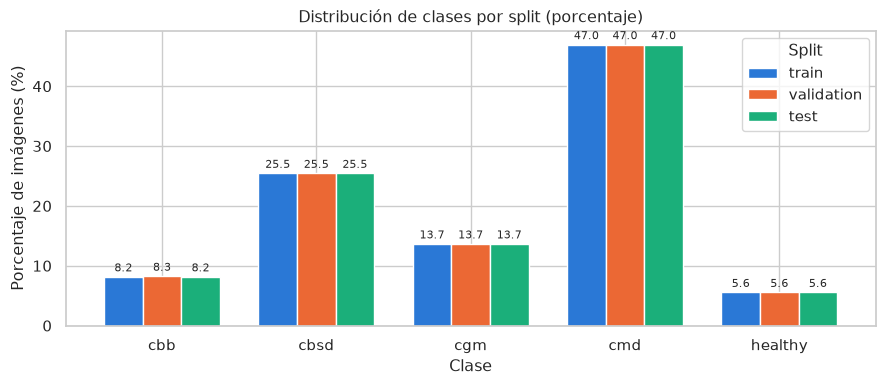

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
df_dist_pct.plot(kind="bar", ax=ax, width=0.75,
                 color=["#2a78d6", "#eb6834", "#1baf7a"], edgecolor="white")
ax.set_title("Distribución de clases por split (porcentaje)")
ax.set_xlabel("Clase")
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Split")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

**Resultado e interpretación.** El dataset tiene 9430 imágenes repartidas en 5656 / 1889 / 1885 (60 % / 20 % / 20 %). Tres observaciones importantes para lo que sigue:

- **Fuerte desbalance:** `cmd` concentra el 47 % de las imágenes, `cbsd` el 25.5 %, `cgm` el 13.7 %, `cbb` el 8.2 % y `healthy` solo el 5.6 %. Un clasificador trivial que siempre prediga `cmd` obtendría **accuracy = 0.470** en test: ese es el piso que cualquier modelo debe superar para haber aprendido algo, y la razón por la que en la evaluación no bastará con la accuracy.
- **CBB es la enfermedad menos representada** (466 imágenes en train), tal como indica el enunciado. En esta versión del dataset (`cassava/0.1.0`) la hoja sana es incluso más escasa, así que reportaremos con detalle ambas clases minoritarias, con foco en CBB.
- **Los tres splits están estratificados:** las proporciones por clase coinciden hasta el decimal entre `train`, `validation` y `test`. Esto garantiza que la `val_loss` que usa `EarlyStopping` sea representativa del test y que las métricas finales sean comparables entre experimentos.

### **1.4 Dimensiones originales de las imágenes y ejemplos por clase**

Medimos el tamaño original de una muestra de imágenes (esto justifica el `resize` del preprocesamiento) y visualizamos dos ejemplos por clase para entender qué tan distinguibles son visualmente las categorías.

In [7]:
# Dimensiones (alto, ancho) de las primeras 300 imágenes de entrenamiento
formas = np.array([img.shape[:2] for img, _ in ds_train_raw.take(300)])
df_formas = pd.DataFrame(formas, columns=["alto", "ancho"])
print("Resumen de dimensiones originales (muestra de 300 imágenes):")
print(df_formas.describe().loc[["min", "mean", "max"]].round(0).to_string())
print("\nCombinaciones (alto, ancho) más frecuentes:")
print(df_formas.value_counts().head(5).to_string())

Resumen de dimensiones originales (muestra de 300 imágenes):
       alto  ancho
min   500.0  499.0
mean  575.0  619.0
max   942.0  901.0

Combinaciones (alto, ancho) más frecuentes:
alto  ancho
666   500      70
500   888      48
      666      34
      625      27
      500      22


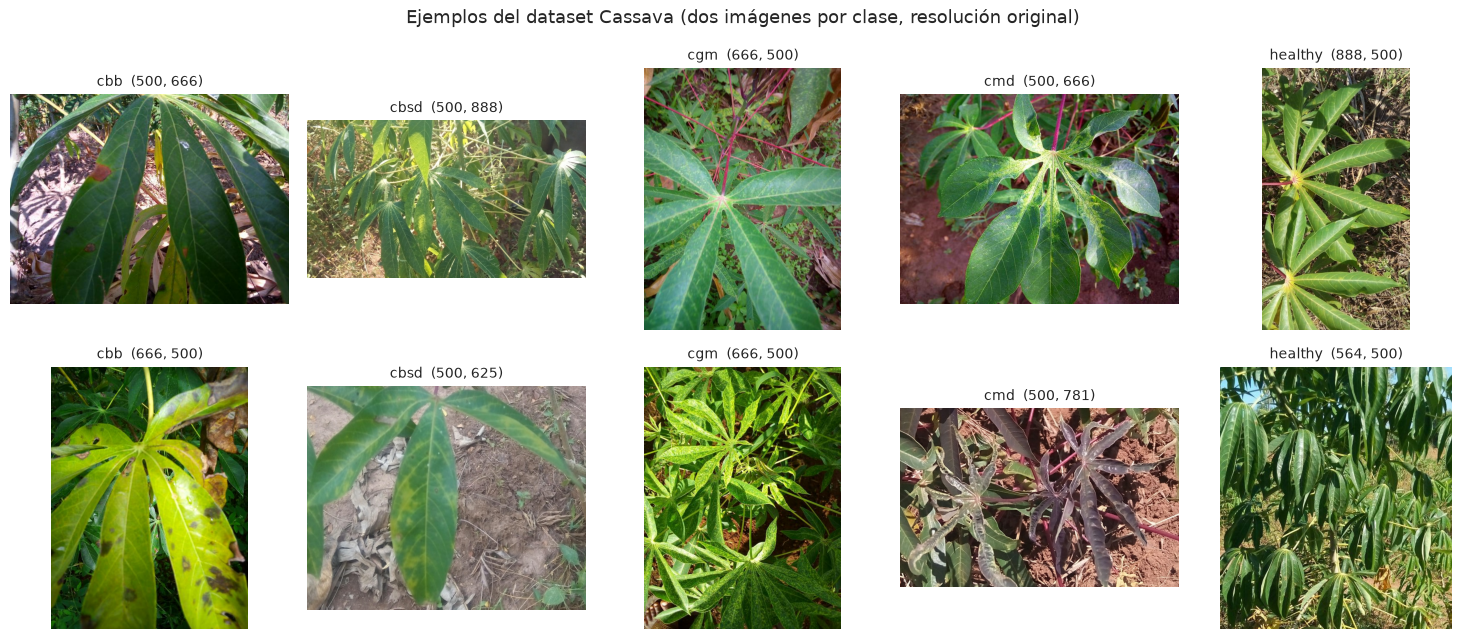

In [8]:
# Dos ejemplos por clase
ejemplos: dict[int, list] = {i: [] for i in range(NUM_CLASSES)}
for img, lbl in ds_train_raw:
    lbl = int(lbl)
    if len(ejemplos[lbl]) < 2:
        ejemplos[lbl].append(img.numpy())
    if all(len(v) == 2 for v in ejemplos.values()):
        break

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 6.5))
for j in range(NUM_CLASSES):
    for i in range(2):
        axes[i, j].imshow(ejemplos[j][i])
        axes[i, j].set_title(f"{class_names[j]}  {ejemplos[j][i].shape[:2]}", fontsize=10)
        axes[i, j].axis("off")
fig.suptitle("Ejemplos del dataset Cassava (dos imágenes por clase, resolución original)", fontsize=13)
plt.tight_layout()
plt.show()

**Resultado e interpretación.** Las imágenes originales no son cuadradas ni de tamaño fijo: el lado corto es casi siempre 500 px y el largo va de 499 a 942 px, con formatos típicos de foto de celular en vertical (666×500) u horizontal (500×888). Esto tiene dos consecuencias:

- **El `resize` a 160×160 es obligatorio** (una CNN necesita tensores de forma fija para armar lotes) y deforma ligeramente la relación de aspecto. Como la deformación afecta por igual a todas las clases y se aplica idéntica en train, validación y test, no introduce sesgo entre clases. Pasar de ~500×666 a 160×160 descarta cerca del 92 % de los píxeles, así que los síntomas finos (puntos pequeños de CBB, estrías de CBSD) se ven atenuados: es una limitación conocida del protocolo del taller.
- **La resolución no es un proxy del target:** los tamaños son los mismos en todas las clases, así que el modelo no puede "hacer trampa" con el formato de la foto.

Los ejemplos muestran por qué el problema es difícil: son fotos de campo con fondo de suelo, otras plantas, sombras e iluminación variable; los síntomas de `cbsd` (amarillamiento junto a las venas) y `cbb` (manchas y necrosis en el borde) se parecen entre sí y a hojas viejas, mientras que `cmd` (mosaico y deformación) es la más reconocible a simple vista. Esa dificultad visual, sumada al desbalance, anticipa que CBB será la clase más difícil.

### **1.5 Leakage check**

Checklist antes de cualquier partición o transformación:

| Pregunta | Respuesta | Decisión |
|-|-|-|
| ¿Alguna feature está derivada del target? | No: la única feature es la imagen cruda; la etiqueta la asignó un experto a partir de esa misma imagen, no al revés. | Se mantiene |
| ¿Hay información post-evento (no disponible en producción)? | No: en producción un agricultor toma la foto y el modelo predice; la foto es lo único que existirá en ese momento. | N/A |
| ¿Existen proxies del target (metadatos, nombre de archivo, resolución)? | Los splits de `tfds` no exponen metadatos ni nombres de archivo. La resolución es casi constante entre clases (sección 1.4), así que no sirve como proxy. | No se usan metadatos |
| ¿Los splits se solapan? | `train`, `validation` y `test` vienen definidos por los autores del dataset y son disjuntos. **No** re-particionamos para cumplir la instrucción de usar siempre los mismos conjuntos de validación y test. | Splits oficiales |
| ¿El preprocesamiento aprende parámetros de los datos? | No: `resize` y la normalización de píxeles usan constantes fijas (160×160, división entre 255), no estadísticas estimadas sobre test. | Sin fuga |
| ¿El backbone preentrenado vio estas imágenes? | MobileNetV2 fue preentrenado en ImageNet (objetos genéricos), que no contiene el dataset Cassava. | Sin fuga |

**Decisión documentada:** el conjunto `validation` se usa **únicamente** para `EarlyStopping`; el conjunto `test` se evalúa **una sola vez** por modelo, al final, y nunca interviene en ninguna decisión de entrenamiento.

# **2. Preprocesamiento**

**Qué se hace:** (i) redimensionamos todas las imágenes a 160×160, (ii) construimos los tres subconjuntos de entrenamiento de 150, 800 y 2500 imágenes de forma **anidada** (150 ⊂ 800 ⊂ 2500) a partir de un único barajado con semilla, (iii) materializamos validación y test una sola vez para que sean idénticos en los seis experimentos, y (iv) dejamos la normalización de píxeles **dentro del modelo** (capa `Rescaling`), que es el equivalente en Keras de meter el escalado dentro del `Pipeline`: la transformación viaja con el modelo y no puede aplicarse de forma distinta en entrenamiento y producción.

**¿Por qué subconjuntos anidados?** Si tomáramos 150, 800 y 2500 imágenes independientes, la diferencia de desempeño mezclaría dos efectos: "más datos" y "otros datos". Con subconjuntos anidados, el conjunto grande **extiende** al pequeño, así que la única diferencia entre experimentos es la cantidad de datos, que es exactamente lo que el taller pide analizar.

**¿Por qué 160×160?** Es la resolución exigida por el enunciado y además es uno de los tamaños con los que MobileNetV2 fue entrenado en ImageNet (existen pesos para 96, 128, 160, 192 y 224), lo que hace que el transfer learning sea directo.

In [9]:
def redimensionar(imagen: tf.Tensor, etiqueta: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    """Redimensiona la imagen a IMG_SIZE x IMG_SIZE (interpolación bilineal) y la deja en uint8."""
    imagen = tf.image.resize(imagen, (IMG_SIZE, IMG_SIZE), method="bilinear")
    return tf.cast(imagen, tf.uint8), etiqueta


def a_numpy(ds: tf.data.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """Materializa un dataset (imagen, etiqueta) ya redimensionado en dos arreglos de numpy."""
    X, y = zip(*tfds.as_numpy(ds.map(redimensionar, num_parallel_calls=AUTOTUNE)))
    return np.stack(X), np.array(y, dtype=np.int64)


# Un ÚNICO barajado de todo el split de entrenamiento, con semilla y sin re-barajar entre
# iteraciones, y nos quedamos con las primeras 2500 imágenes: los subconjuntos de 150 y 800
# serán simplemente los primeros 150 y 800 elementos de este arreglo (anidados).
n_train_total: int = ds_info.splits["train"].num_examples
ds_train_2500 = ds_train_raw.shuffle(n_train_total, seed=SEED, reshuffle_each_iteration=False).take(max(TRAIN_SIZES))

t0 = time.time()
X_train_2500, y_train_2500 = a_numpy(ds_train_2500)
X_val, y_val_chk = a_numpy(ds_val_raw)
X_test, y_test_chk = a_numpy(ds_test_raw)
print(f"Materialización en memoria: {time.time() - t0:.1f} s")

# Validación y test se materializan UNA vez y son los mismos en los 6 experimentos
assert np.array_equal(y_val, y_val_chk) and np.array_equal(y_test, y_test_chk)
print("X_train_2500:", X_train_2500.shape, X_train_2500.dtype)
print("X_val:       ", X_val.shape)
print("X_test:      ", X_test.shape)
print(f"Memoria total: {(X_train_2500.nbytes + X_val.nbytes + X_test.nbytes) / 1e6:.0f} MB")

Materialización en memoria: 9.8 s
X_train_2500: (2500, 160, 160, 3) uint8
X_val:        (1889, 160, 160, 3)
X_test:       (1885, 160, 160, 3)
Memoria total: 482 MB


In [10]:
# Subconjuntos anidados de entrenamiento: 150 ⊂ 800 ⊂ 2500
X_train_por_tamano: dict[int, np.ndarray] = {n: X_train_2500[:n] for n in TRAIN_SIZES}
y_train_por_tamano: dict[int, np.ndarray] = {n: y_train_2500[:n] for n in TRAIN_SIZES}

df_dist_train = pd.DataFrame(
    {f"train_{n}": pd.Series(y).value_counts().reindex(range(NUM_CLASSES), fill_value=0)
     for n, y in y_train_por_tamano.items()}
)
df_dist_train.index = class_names
df_dist_train["validation"] = df_dist["validation"].values
df_dist_train["test"] = df_dist["test"].values

print("Imágenes por clase en cada subconjunto de entrenamiento (y en val/test):")
print(df_dist_train.to_string())
print("\nPorcentaje por clase (%):")
print((df_dist_train / df_dist_train.sum() * 100).round(1).to_string())

Imágenes por clase en cada subconjunto de entrenamiento (y en val/test):
         train_150  train_800  train_2500  validation  test
cbb             15         76         217         156   155
cbsd            38        215         639         482   481
cgm             20        103         353         258   258
cmd             67        361        1158         887   886
healthy         10         45         133         106   105

Porcentaje por clase (%):
         train_150  train_800  train_2500  validation  test
cbb           10.0        9.5         8.7         8.3   8.2
cbsd          25.3       26.9        25.6        25.5  25.5
cgm           13.3       12.9        14.1        13.7  13.7
cmd           44.7       45.1        46.3        47.0  47.0
healthy        6.7        5.6         5.3         5.6   5.6


**Resultado e interpretación.** Al barajar con semilla y tomar los primeros 150 / 800 / 2500 ejemplos, los subconjuntos conservan aproximadamente la distribución del dataset completo sin necesidad de estratificar (10.0 %, 9.5 % y 8.7 % de CBB frente al 8.2 % global). Lo relevante es el **número absoluto de ejemplos de las clases minoritarias**:

| Subconjunto | CBB | healthy | cgm | cbsd | cmd |
|-|-|-|-|-|-|
| 150 imágenes | 15 | 10 | 20 | 38 | 67 |
| 800 imágenes | 76 | 45 | 103 | 215 | 361 |
| 2500 imágenes | 217 | 133 | 353 | 639 | 1158 |

Con 150 imágenes, la red ve solo **15 hojas con CBB y 10 sanas**: menos de un lote de 32. Aprender desde cero filtros que distingan manchas bacterianas de un amarillamiento viral con 15 ejemplos es prácticamente imposible; esta tabla es la clave para interpretar después el F1 de CBB. Validación (1889) y test (1885) son exactamente los mismos en los seis experimentos, como exige el enunciado.

In [11]:
def a_dataset(X: np.ndarray, y: np.ndarray, barajar: bool) -> tf.data.Dataset:
    """Empaqueta arreglos en un tf.data.Dataset por lotes; baraja cada época solo si es entrenamiento."""
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if barajar:
        ds = ds.shuffle(len(X), seed=SEED)   # re-ordena los lotes en cada época, sin cambiar qué imágenes hay
    # Guardamos en memoria como uint8 (4x menos espacio) y convertimos a float32 lote a lote
    return ds.batch(BATCH_SIZE).map(lambda x, y: (tf.cast(x, tf.float32), y)).prefetch(AUTOTUNE)


# Val y test NO se barajan: así el orden de y_test coincide con el de las predicciones.
# Se construyen UNA sola vez y son los mismos objetos en los 6 experimentos.
ds_val = a_dataset(X_val, y_val, barajar=False)
ds_test = a_dataset(X_test, y_test, barajar=False)

# El pipeline de entrenamiento se crea dentro de cada experimento (sección 3.4), justo
# después de fijar la semilla, para que el orden de barajado sea idéntico entre enfoques.
# Chequeo rápido de un lote:
for x_b, y_b in a_dataset(X_train_por_tamano[150], y_train_por_tamano[150], barajar=True).take(1):
    print("Lote de entrenamiento:", x_b.shape, x_b.dtype, "| etiquetas:", y_b.numpy()[:10])

Lote de entrenamiento: (32, 160, 160, 3) <dtype: 'float32'> | etiquetas: [1 3 1 3 2 3 2 3 4 1]


**Resultado e interpretación.** Cada lote tiene forma `(32, 160, 160, 3)`: las imágenes se guardan en memoria en `uint8` sin normalizar (4 veces menos memoria que en `float32`), se convierten a `float32` lote a lote y el escalado a `[0, 1]` o `[-1, 1]` se hace dentro de cada modelo. `BATCH_SIZE=32` es el valor estándar de los laboratorios del curso y da 5 pasos por época con 150 imágenes, 25 con 800 y 79 con 2500: incluso el experimento más pequeño hace varias actualizaciones de gradiente por época, lo que hace que `patience=4` tenga sentido en los tres tamaños.

# **3. Modelado: CNN desde cero y Transfer Learning**

**Qué se hace:** definimos una función constructora para cada enfoque y una función de entrenamiento única que se reutiliza en los seis experimentos. Ambos modelos comparten **exactamente la misma cabeza de clasificación** (`GlobalAveragePooling2D → Dense(128, relu) → Dropout(0.5) → Dense(5, softmax)`), definida una sola vez en `cabeza_clasificacion`, de modo que la única diferencia entre enfoques sea el extractor de características: tres bloques convolucionales inicializados al azar vs. MobileNetV2 preentrenado y congelado.

### **3.1 Cabeza de clasificación compartida y elección de la función de pérdida**

- **Softmax** en la salida: el problema es multiclase de una sola etiqueta, así que necesitamos una distribución de probabilidad sobre las 5 clases (suman 1).
- **`sparse_categorical_crossentropy`**: las etiquetas vienen como enteros (0-4) de `tfds`, no en one-hot; es la entropía cruzada estándar para softmax sin necesidad de codificar el target.
- **Adam con `learning_rate=1e-3`** (valor por defecto) en ambos enfoques: mantener el mismo optimizador y la misma tasa evita que la comparación entre enfoques dependa de un ajuste de hiperparámetros distinto.
- **`Dropout(0.5)`** está exigido por el enunciado y es especialmente importante en el experimento con 150 imágenes, donde la capa densa de 128 neuronas podría memorizar el conjunto de entrenamiento.

In [12]:
def cabeza_clasificacion(x: tf.Tensor) -> tf.Tensor:
    """Cabeza de clasificación común a los dos enfoques: GAP -> Dense(128, relu) -> Dropout(0.5) -> softmax."""
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.5, name="dropout_05")(x)
    return layers.Dense(NUM_CLASSES, activation="softmax", name="salida_softmax")(x)


def compilar(model: keras.Model) -> keras.Model:
    """Compila con la misma configuración (Adam 1e-3, entropía cruzada, accuracy) para todos los experimentos."""
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

### **3.2 Modelo 1: CNN desde cero**

Arquitectura exigida: 3 bloques `Conv2D(3×3) + ReLU + MaxPooling2D` con 32, 64 y 128 filtros, seguidos de la cabeza compartida. Decisiones propias:

- **`Rescaling(1/255)`** como primera capa: lleva los píxeles de `[0, 255]` a `[0, 1]`. Sin normalizar, las activaciones iniciales serían enormes y Adam tardaría más en converger o divergiría.
- **`padding='same'`**: conserva la resolución espacial dentro de cada bloque y deja que sea `MaxPooling2D` quien la reduzca a la mitad (160 → 80 → 40 → 20). Así cada bloque duplica los filtros mientras reduce el área, el patrón clásico de una CNN.
- Los filtros crecen (32 → 64 → 128) porque las primeras capas detectan pocos patrones simples (bordes, cambios de color) y las capas profundas combinan esos patrones en muchos más conceptos (manchas, texturas de mosaico).

In [13]:
def construir_cnn() -> keras.Model:
    """Modelo 1: CNN desde cero con 3 bloques Conv2D+ReLU+MaxPooling (32, 64, 128 filtros, kernel 3x3)."""
    entradas = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="imagen")
    x = layers.Rescaling(1.0 / 255, name="rescaling_0_1")(entradas)     # [0, 255] -> [0, 1]
    for i, filtros in enumerate([32, 64, 128], start=1):
        x = layers.Conv2D(filtros, (3, 3), activation="relu", padding="same", name=f"conv{i}_{filtros}")(x)
        x = layers.MaxPooling2D((2, 2), name=f"pool{i}")(x)
    salidas = cabeza_clasificacion(x)
    return compilar(keras.Model(entradas, salidas, name="cnn_desde_cero"))


keras.utils.set_random_seed(SEED)
construir_cnn().summary()

Model: "cnn_desde_cero"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_0_1 (Rescaling)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_32 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_64 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_128 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_05 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_softmax (Dense)          │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

### **3.3 Modelo 2: Transfer Learning con MobileNetV2**

**¿Por qué MobileNetV2 y no EfficientNetB0?**

| Criterio | MobileNetV2 | EfficientNetB0 |
|-|-|-|
| Parámetros del backbone (sin top) | ~2.3 M | ~4.0 M |
| Diseñado para | Dispositivos móviles (convoluciones *depthwise separable*, bloques residuales invertidos) | Escalado compuesto de resolución/ancho/profundidad |
| Pesos ImageNet disponibles a 160×160 | Sí (tamaño nativo) | Sí (interpolados; nativo 224×224) |
| Preprocesamiento esperado | Píxeles en `[-1, 1]` | Píxeles crudos `[0, 255]` (normalización interna) |

Elegimos **MobileNetV2** porque (i) el contexto del taller son aplicaciones como PlantVillage o Nuru que corren **en el teléfono del agricultor**, y MobileNetV2 fue diseñado exactamente para ese caso; (ii) tiene pesos entrenados en ImageNet a 160×160, la resolución exigida; y (iii) con menos parámetros y un extractor congelado, el entrenamiento es rápido incluso en la GPU modesta que usamos.

**Capas congeladas.** Cargamos el backbone con `include_top=False` (sin el clasificador de 1000 clases de ImageNet) y `trainable=False`: los 2.3 M de parámetros del extractor **no se actualizan**; solo se entrenan los ~165 k parámetros de la cabeza. Congelar también fija las capas `BatchNormalization` en modo inferencia, lo que evita que las estadísticas aprendidas en ImageNet se destruyan con lotes pequeños (con 150 imágenes hay solo 5 lotes por época). Verificaremos en el `summary()` la separación entre parámetros entrenables y no entrenables.

**Preprocesamiento.** `keras.applications.mobilenet_v2.preprocess_input` transforma `[0, 255]` en `[-1, 1]` mediante `x / 127.5 - 1`; implementamos esa misma operación con la capa `Rescaling(scale=1/127.5, offset=-1)` dentro del modelo, de modo que la normalización viaje con el modelo igual que en el Modelo 1.

In [14]:
def construir_transfer() -> keras.Model:
    """Modelo 2: MobileNetV2 preentrenado en ImageNet, congelado, con la misma cabeza de clasificación."""
    backbone = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,        # sin la capa final de 1000 clases de ImageNet
        weights="imagenet",
    )
    backbone.trainable = False    # congelamos TODO el extractor de características (no hay fine-tuning)

    entradas = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="imagen")
    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="rescaling_menos1_1")(entradas)  # == preprocess_input
    x = backbone(x, training=False)   # training=False: BatchNorm siempre en modo inferencia
    salidas = cabeza_clasificacion(x)
    return compilar(keras.Model(entradas, salidas, name="transfer_mobilenetv2"))


keras.utils.set_random_seed(SEED)
modelo_tl_demo = construir_transfer()
modelo_tl_demo.summary()

n_entrenables = sum(int(np.prod(w.shape)) for w in modelo_tl_demo.trainable_weights)
n_congelados = sum(int(np.prod(w.shape)) for w in modelo_tl_demo.non_trainable_weights)
print(f"\nParámetros entrenables (cabeza):      {n_entrenables:>10,}")
print(f"Parámetros congelados (MobileNetV2):  {n_congelados:>10,}")
backbone_demo = next(l for l in modelo_tl_demo.layers if isinstance(l, keras.Model))
print(f"Capas del backbone '{backbone_demo.name}' congeladas: "
      f"{sum(not l.trainable for l in backbone_demo.layers)} de {len(backbone_demo.layers)}")
del modelo_tl_demo

Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_menos1_1 (Rescaling)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_05 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_softmax (Dense)          │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros entrenables (cabeza):         164,613
Parámetros congelados (MobileNetV2):   2,257,984
Capas del backbone 'mobilenetv2_1.00_160' congeladas: 154 de 154


**Resultado e interpretación de los `summary()`.**

| | CNN desde cero | Transfer Learning (MobileNetV2) |
|-|-|-|
| Parámetros totales | 110 405 | 2 422 597 |
| Parámetros entrenables | 110 405 (100 %) | 164 613 (6.8 %) |
| Parámetros congelados | 0 | 2 257 984 (154 de 154 capas del backbone) |
| Salida del extractor (entrada al GAP) | 20×20×128 | 5×5×1280 |

- La **cabeza es idéntica** en los dos modelos (`gap → dense_128 → dropout_05 → salida_softmax`). Que `dense_128` tenga 163 968 parámetros en transfer learning y 16 512 en la CNN se debe únicamente a que el vector que entrega el `GlobalAveragePooling2D` tiene 1280 componentes (MobileNetV2) frente a 128 (tercer bloque de la CNN); la arquitectura de la cabeza no cambia.
- El backbone comprime cada imagen de 160×160×3 a un mapa de 5×5×1280 características semánticas (aprendidas en 1.2 millones de imágenes de ImageNet), mientras que la CNN desde cero debe descubrir sus 128 filtros finales a partir de, como mucho, 2500 fotos de hojas.
- Un detalle que importa para el análisis: la CNN completa tiene **menos parámetros entrenables** (110 k) que la sola cabeza del transfer learning (165 k). La ventaja del transfer learning no será, por tanto, "más capacidad", sino la **calidad de las características de entrada** a la cabeza.

### **3.4 Entrenamiento de los seis experimentos**

Una única función `entrenar` ejecuta `model.fit` con la configuración común; el bucle recorre las 6 combinaciones (2 enfoques × 3 tamaños). Puntos clave:

- **Modelo nuevo en cada experimento**: la función constructora crea pesos frescos (y para transfer learning recarga los pesos de ImageNet). Reutilizar el mismo objeto haría que el experimento con 800 imágenes arrancara con los pesos ya entrenados con 150, y dejaría de ser "desde cero".
- **Misma semilla antes de cada construcción**: los tres tamaños de un mismo enfoque parten de la misma inicialización y del mismo orden de barajado (el pipeline `tf.data` se crea dentro de `entrenar`, después de fijar la semilla), así que la diferencia entre ellos es solo la cantidad de datos. Junto con `enable_op_determinism()` (sección 0), esto hace que los seis resultados sean reproducibles exactamente.
- **`EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)`**: exigido por el enunciado. `restore_best_weights=True` hace que el modelo evaluado sea el de la época con menor `val_loss` y no el de la última época (que ya venía empeorando cuando se activó la parada). Monitoreamos `val_loss` y no `val_accuracy` porque la pérdida es continua y detecta el sobreajuste antes de que se refleje en la accuracy.
- **Mismo `ds_val` en todos los casos**, tal como pide el enunciado.

In [15]:
def entrenar(enfoque: str, constructor, n_train: int) -> dict:
    """Construye un modelo nuevo y lo entrena con n_train imágenes usando la configuración común; devuelve modelo, historia y tiempos."""
    keras.utils.set_random_seed(SEED)
    model = constructor()
    ds_train = a_dataset(X_train_por_tamano[n_train], y_train_por_tamano[n_train], barajar=True)
    early_stopping = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1)

    t0 = time.time()
    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=EPOCHS,
        callbacks=[early_stopping],
        verbose=2,
    )
    duracion = time.time() - t0

    hist = history.history
    mejor_epoca = int(np.argmin(hist["val_loss"])) + 1
    return {
        "enfoque": enfoque, "n_train": n_train, "model": model, "history": hist,
        "epocas_ejecutadas": len(hist["loss"]), "mejor_epoca": mejor_epoca,
        "val_loss_min": float(hist["val_loss"][mejor_epoca - 1]),
        "val_acc_mejor": float(hist["val_accuracy"][mejor_epoca - 1]),
        "tiempo_s": duracion,
    }


ENFOQUES = {"CNN desde cero": construir_cnn, "Transfer Learning": construir_transfer}
experimentos: dict[tuple[str, int], dict] = {}

for enfoque, constructor in ENFOQUES.items():
    for n in TRAIN_SIZES:
        print(f"\n{'=' * 78}\n  {enfoque} | {n} imágenes de entrenamiento\n{'=' * 78}")
        experimentos[(enfoque, n)] = entrenar(enfoque, constructor, n)
        r = experimentos[(enfoque, n)]
        print(f"-> {r['epocas_ejecutadas']} épocas ({r['tiempo_s']:.0f} s); mejor época = {r['mejor_epoca']} "
              f"con val_loss = {r['val_loss_min']:.4f}, val_accuracy = {r['val_acc_mejor']:.4f}")


  CNN desde cero | 150 imágenes de entrenamiento
Epoch 1/20


5/5 - 9s - 2s/step - accuracy: 0.3667 - loss: 1.5641 - val_accuracy: 0.4696 - val_loss: 1.4161


Epoch 2/20


5/5 - 1s - 264ms/step - accuracy: 0.4467 - loss: 1.4680 - val_accuracy: 0.4696 - val_loss: 1.3318


Epoch 3/20


...

Epoch 9/20


79/79 - 6s - 75ms/step - accuracy: 0.7932 - loss: 0.5525 - val_accuracy: 0.7141 - val_loss: 0.7734


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 5.


-> 9 épocas (61 s); mejor época = 5 con val_loss = 0.7664, val_accuracy = 0.7120


In [16]:
df_entrenamiento = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("model", "history")} for r in experimentos.values()
]).set_index(["enfoque", "n_train"])
print("Resumen del entrenamiento (val = conjunto de validación, mejor época según val_loss):")
print(df_entrenamiento.round(4).to_string())

Resumen del entrenamiento (val = conjunto de validación, mejor época según val_loss):
                           epocas_ejecutadas  mejor_epoca  val_loss_min  val_acc_mejor  tiempo_s
enfoque           n_train                                                                       
CNN desde cero    150                     19           15        1.3080         0.4696   33.3355
                  800                     20           20        1.0900         0.6162   43.7567
                  2500                    19           15        1.0279         0.6326   76.5708
Transfer Learning 150                     10            6        0.9935         0.6141   37.5472
                  800                     12            8        0.8339         0.7009   52.2286
                  2500                     9            5        0.7664         0.7120   60.8344


**Resultado e interpretación del entrenamiento.**

- **La CNN desde cero casi nunca activa el `EarlyStopping`**: con 800 imágenes agota las 20 épocas y su mejor época es la última (`val_loss` seguía bajando), y con 150 y 2500 se detiene en la época 19 tras alcanzar el mínimo en la 15. Sus mínimos de `val_loss` (1.308 → 1.090 → 1.028) quedan lejos de los del transfer learning: la red aprende lento y, dentro del presupuesto de 20 épocas, no llega a converger. Con 150 imágenes, la `val_accuracy` de la mejor época (0.4696) es exactamente la proporción de `cmd` en validación: el modelo no salió del clasificador mayoritario.
- **El transfer learning converge en 5-8 épocas** y el `EarlyStopping` lo detiene en 10, 12 y 9 épocas: la cabeza sobre características fijas aprende rápido y, a partir de ahí, empieza a sobreajustar (lo veremos en las curvas). Sus `val_loss` mínimos (0.994 → 0.834 → 0.766) mejoran de forma consistente con más datos.
- **El costo computacional es comparable** (33-77 s por experimento en una GPU RTX 3050): MobileNetV2 hace más cálculo por paso, pero necesita menos de la mitad de las épocas. Con `restore_best_weights=True` cada modelo queda con los pesos de su mejor época, que son los que se evalúan en test a continuación.

# **4. Evaluación y presentación de resultados**

**Qué se hace:** evaluamos los seis modelos **una sola vez** sobre el mismo conjunto de test (1885 imágenes) y reportamos, para cada uno: accuracy global, balanced accuracy, F1-score por clase (con atención a CBB), `classification_report`, matriz de confusión y las curvas de loss/accuracy de entrenamiento y validación. Organizamos todo en tablas y figuras que enfrentan los dos enfoques en cada tamaño de datos.

**¿Por qué estas métricas?** El dataset está desbalanceado (sección 1.3): un modelo que prediga siempre la clase mayoritaria obtendría una accuracy engañosamente alta. Por eso acompañamos la accuracy con la **balanced accuracy** (promedio del recall por clase, que castiga ignorar las clases pequeñas) y con el **F1 por clase**, que combina precisión y recall y es la métrica adecuada para vigilar a CBB, la clase minoritaria que el enunciado pide observar.

### **4.1 Accuracy global y F1 por clase en test**

In [17]:
def evaluar(model: keras.Model, ds: tf.data.Dataset, y_true: np.ndarray) -> tuple[dict, np.ndarray]:
    """Predice sobre un dataset y devuelve accuracy, balanced accuracy y F1 por clase, junto con y_pred."""
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    f1_por_clase = f1_score(y_true, y_pred, average=None, labels=range(NUM_CLASSES), zero_division=0)
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_por_clase.mean(),
        **{f"f1_{c}": f1_por_clase[i] for i, c in enumerate(class_names)},
    }
    return metricas, y_pred


predicciones: dict[tuple[str, int], np.ndarray] = {}
filas: list[dict] = []
for (enfoque, n), r in experimentos.items():
    metricas, predicciones[(enfoque, n)] = evaluar(r["model"], ds_test, y_test)
    filas.append({"enfoque": enfoque, "n_train": n, **metricas,
                  "epocas": r["epocas_ejecutadas"], "mejor_epoca": r["mejor_epoca"]})

df_resultados = pd.DataFrame(filas).set_index(["enfoque", "n_train"])
print("Métricas en TEST para los seis experimentos:")
print(df_resultados.round(4).to_string())

Métricas en TEST para los seis experimentos:
                           accuracy  balanced_accuracy  f1_macro  f1_cbb  f1_cbsd  f1_cgm  f1_cmd  f1_healthy  epocas  mejor_epoca
enfoque           n_train                                                                                                         
CNN desde cero    150        0.4700             0.2000    0.1279  0.0000   0.0000  0.0000  0.6395      0.0000      19           15
                  800        0.6191             0.3387    0.2943  0.0854   0.6150  0.0000  0.7714      0.0000      20           20
                  2500       0.6313             0.3459    0.2985  0.0732   0.6354  0.0000  0.7840      0.0000      19           15
Transfer Learning 150        0.6154             0.4242    0.4426  0.1728   0.5722  0.3776  0.7711      0.3194      10            6
                  800        0.6960             0.5572    0.5772  0.3438   0.6740  0.4989  0.8229      0.5464      12            8
                  2500       0.7183   

In [18]:
# Tablas comparativas: enfoques en columnas, tamaño de datos en filas
tabla_acc = df_resultados["accuracy"].unstack("enfoque").loc[TRAIN_SIZES]
tabla_bacc = df_resultados["balanced_accuracy"].unstack("enfoque").loc[TRAIN_SIZES]
tabla_f1cbb = df_resultados["f1_cbb"].unstack("enfoque").loc[TRAIN_SIZES]
tabla_f1macro = df_resultados["f1_macro"].unstack("enfoque").loc[TRAIN_SIZES]

for nombre, t in [("Accuracy", tabla_acc), ("Balanced accuracy", tabla_bacc),
                  ("F1 macro", tabla_f1macro), ("F1 de CBB (clase minoritaria)", tabla_f1cbb)]:
    t = t.copy()
    t["diferencia (TL - CNN)"] = t["Transfer Learning"] - t["CNN desde cero"]
    print(f"\n--- {nombre} en test ---")
    print(t.round(4).to_string())


--- Accuracy en test ---
enfoque  CNN desde cero  Transfer Learning  diferencia (TL - CNN)
n_train                                                          
150              0.4700             0.6154                 0.1454
800              0.6191             0.6960                 0.0769
2500             0.6313             0.7183                 0.0870

--- Balanced accuracy en test ---
enfoque  CNN desde cero  Transfer Learning  diferencia (TL - CNN)
n_train                                                          
150              0.2000             0.4242                 0.2242
800              0.3387             0.5572                 0.2184
2500             0.3459             0.5725                 0.2266

--- F1 macro en test ---
enfoque  CNN desde cero  Transfer Learning  diferencia (TL - CNN)
n_train                                                          
150              0.1279             0.4426                 0.3148
800              0.2943             0.5772             

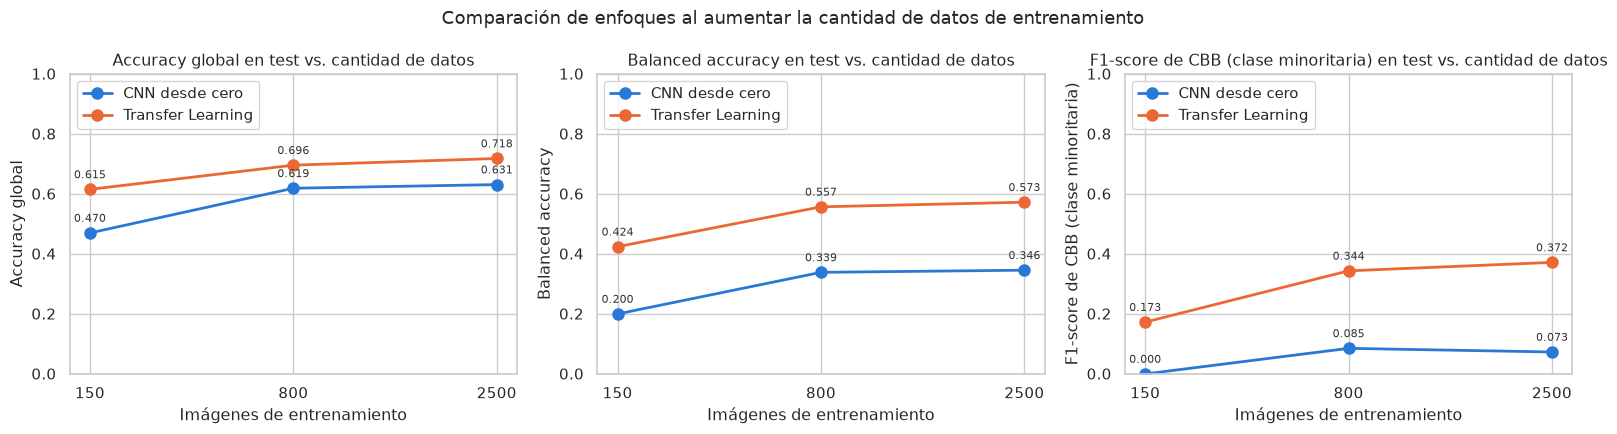

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, (nombre, t) in zip(axes, [("Accuracy global", tabla_acc),
                                   ("Balanced accuracy", tabla_bacc),
                                   ("F1-score de CBB (clase minoritaria)", tabla_f1cbb)]):
    for enfoque in ENFOQUES:
        ax.plot(range(len(TRAIN_SIZES)), t[enfoque].values, marker="o", ms=8, lw=2,
                color=COLORES[enfoque], label=enfoque)
        for i, v in enumerate(t[enfoque].values):
            ax.annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=8, color="#333333")
    ax.set_xticks(range(len(TRAIN_SIZES)))
    ax.set_xticklabels([str(n) for n in TRAIN_SIZES])
    ax.set_xlabel("Imágenes de entrenamiento")
    ax.set_ylabel(nombre)
    ax.set_ylim(0, 1)
    ax.set_title(f"{nombre} en test vs. cantidad de datos")
    ax.legend(loc="upper left")
fig.suptitle("Comparación de enfoques al aumentar la cantidad de datos de entrenamiento", fontsize=13)
plt.tight_layout()
plt.show()

**Resultado e interpretación.**

| Imágenes | Accuracy CNN | Accuracy TL | Brecha | Balanced acc. CNN | Balanced acc. TL | Brecha |
|-|-|-|-|-|-|-|
| 150 | 0.470 | 0.615 | +0.145 | 0.200 | 0.424 | +0.224 |
| 800 | 0.619 | 0.696 | +0.077 | 0.339 | 0.557 | +0.218 |
| 2500 | 0.631 | 0.718 | +0.087 | 0.346 | 0.573 | +0.227 |

- **Con 150 imágenes la CNN desde cero es un clasificador mayoritario**: accuracy 0.470 = proporción de `cmd` y balanced accuracy 0.200 = 1/5, es decir, predice `cmd` para todo. El transfer learning, con las mismas 150 imágenes, ya alcanza 0.615 de accuracy y 0.424 de balanced accuracy.
- **Transfer learning gana en los tres tamaños**, y el transfer learning con 150 imágenes (0.615) casi iguala a la CNN con 2500 imágenes (0.631): necesita unas **16 veces menos datos** para el mismo nivel de accuracy global, y en balanced accuracy lo supera con holgura (0.424 vs 0.346).
- **La brecha depende de la métrica.** En accuracy global la brecha se reduce de 0.145 a ~0.08 al pasar de 150 a 800/2500 imágenes, porque la CNN aprende a separar las dos clases grandes (`cmd` y `cbsd`) y eso pesa mucho en la accuracy. En balanced accuracy la brecha **no se cierra** (≈ 0.22 en los tres tamaños): las ganancias de la CNN vienen casi exclusivamente de las clases mayoritarias. El F1 por clase de la siguiente sección lo confirma.
- Para ambos enfoques la mejora de 800 a 2500 imágenes es mucho menor que la de 150 a 800 (rendimientos decrecientes): triplicar los datos aporta +0.012 (CNN) y +0.022 (TL) de accuracy.

### **4.2 F1-score por clase: mapa de calor y reportes de clasificación**

El mapa de calor enfrenta, fila por fila, los seis experimentos (ordenados por tamaño de datos y enfoque) contra las cinco clases: permite ver de un vistazo qué clases se benefician de más datos y cuáles solo se resuelven con transfer learning.

F1-score por clase en test:
                                cbb   cbsd    cgm    cmd  healthy
experimento                                                      
150 img | CNN desde cero      0.000  0.000  0.000  0.639    0.000
150 img | Transfer Learning   0.173  0.572  0.378  0.771    0.319
800 img | CNN desde cero      0.085  0.615  0.000  0.771    0.000
800 img | Transfer Learning   0.344  0.674  0.499  0.823    0.546
2500 img | CNN desde cero     0.073  0.635  0.000  0.784    0.000
2500 img | Transfer Learning  0.372  0.674  0.528  0.837    0.618


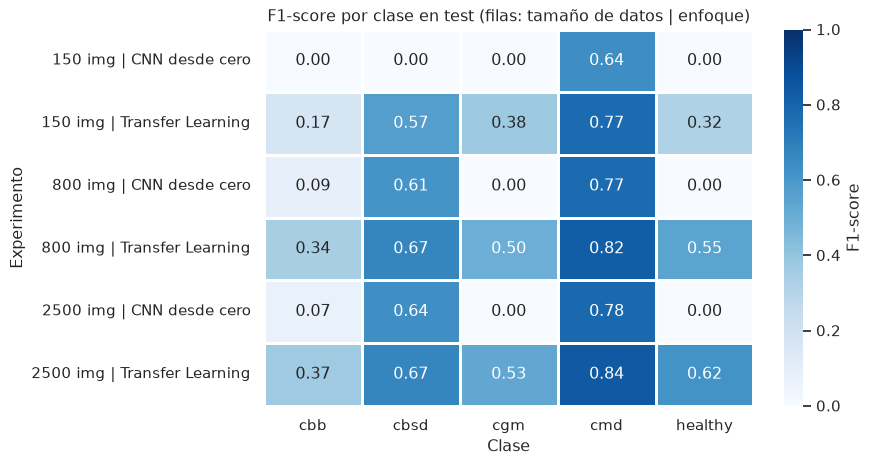

In [20]:
cols_f1 = [f"f1_{c}" for c in class_names]
tabla_f1 = df_resultados[cols_f1].copy()
tabla_f1.columns = class_names
tabla_f1 = tabla_f1.reset_index()
tabla_f1["experimento"] = tabla_f1["n_train"].astype(str) + " img | " + tabla_f1["enfoque"]
tabla_f1 = tabla_f1.sort_values(["n_train", "enfoque"]).set_index("experimento")[class_names]

print("F1-score por clase en test:")
print(tabla_f1.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(tabla_f1, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white", cbar_kws={"label": "F1-score"}, ax=ax)
ax.set_title("F1-score por clase en test (filas: tamaño de datos | enfoque)")
ax.set_xlabel("Clase")
ax.set_ylabel("Experimento")
plt.tight_layout()
plt.show()

In [21]:
for n in TRAIN_SIZES:
    for enfoque in ENFOQUES:
        print(f"\n--- REPORTE DE CLASIFICACIÓN (test) | {enfoque} | {n} imágenes ---")
        print(classification_report(y_test, predicciones[(enfoque, n)], target_names=class_names,
                                    digits=3, zero_division=0))


--- REPORTE DE CLASIFICACIÓN (test) | CNN desde cero | 150 imágenes ---
              precision    recall  f1-score   support

         cbb      0.000     0.000     0.000       155
        cbsd      0.000     0.000     0.000       481
         cgm      0.000     0.000     0.000       258
         cmd      0.470     1.000     0.639       886
     healthy      0.000     0.000     0.000       105

    accuracy                          0.470      1885
   macro avg      0.094     0.200     0.128      1885
weighted avg      0.221     0.470     0.301      1885


--- REPORTE DE CLASIFICACIÓN (test) | Transfer Learning | 150 imágenes ---
              precision    recall  f1-score   support

         cbb      0.239     0.135     0.173       155
        cbsd      0.530     0.622     0.572       481
         cgm      0.474     0.314     0.378       258
         cmd      0.719     0.831     0.771       886
     healthy      0.590     0.219     0.319       105

    accuracy                        

**Resultado e interpretación del F1 por clase.**

- **La CNN desde cero nunca aprende `cgm` ni `healthy`** (F1 = 0.000 en los tres tamaños) y para CBB apenas llega a 0.085 (800) y 0.073 (2500). Los reportes muestran el mecanismo: para CBB tiene precisión alta (0.78 y 0.67) pero recall de 4 %, es decir, solo predice CBB en un puñado de casos en los que está muy segura y el resto lo manda a `cbsd`. Con 2500 imágenes la CNN es, en la práctica, un clasificador de dos clases (`cbsd` vs `cmd`).
- **El transfer learning obtiene F1 > 0 en las cinco clases desde 150 imágenes** y mejora en casi todas al añadir datos: CBB 0.173 → 0.344 → 0.372, `cgm` 0.378 → 0.499 → 0.528, `healthy` 0.319 → 0.546 → 0.618, `cmd` 0.771 → 0.823 → 0.837. `cbsd` se estanca en 0.674 entre 800 y 2500.
- **`cmd` es la clase fácil** para los dos enfoques (F1 0.64-0.84): es la mayoritaria y su síntoma (mosaico amarillo y hojas deformadas) es el más visible incluso a 160×160.
- **CBB sigue siendo la clase más difícil incluso para transfer learning** (0.372 con 2500 imágenes), por debajo de `healthy` (0.618), que tiene *menos* ejemplos de entrenamiento (133 vs 217). La escasez no es la única causa: el problema es la **similitud visual con `cbsd`** (manchas y amarillamiento en ambas), como muestran las matrices de confusión a continuación. En el reporte de 2500 imágenes, CBB tiene precisión 0.52 y recall 0.29: el modelo es conservador y se pierde 7 de cada 10 hojas con CBB, lo que en una aplicación de campo significaría no alertar a tiempo a la mayoría de los agricultores con esta enfermedad.

### **4.3 Matrices de confusión**

Las matrices muestran **entre qué clases** se equivoca cada modelo; en particular, si CBB se pierde dentro de la clase mayoritaria CMD o se confunde con hojas sanas.

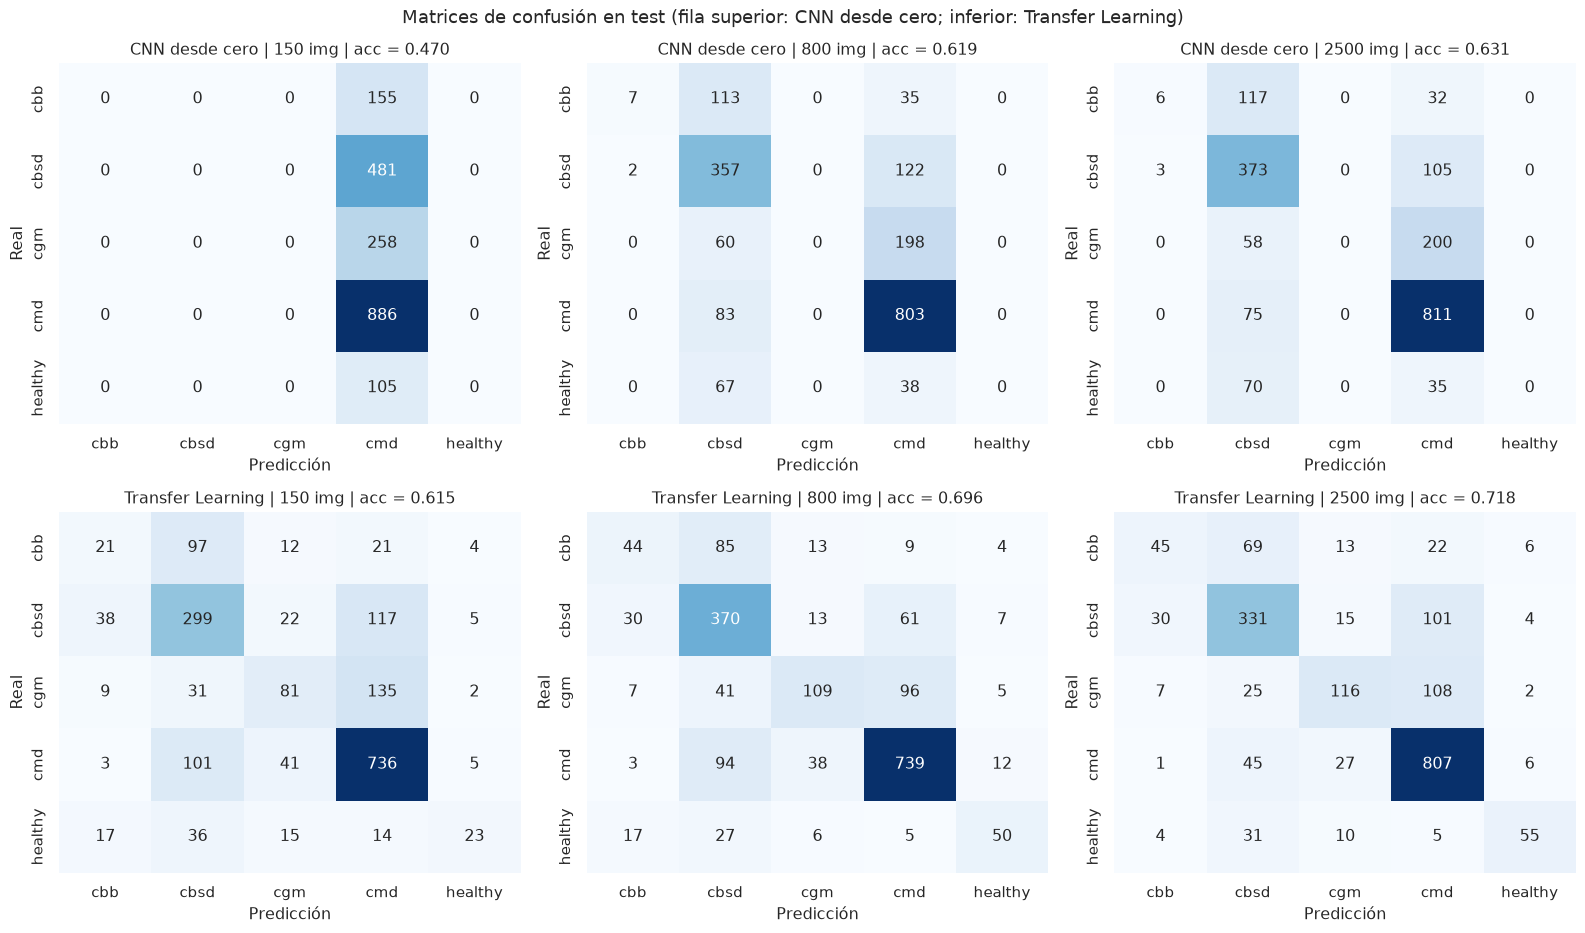

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for i, enfoque in enumerate(ENFOQUES):
    for j, n in enumerate(TRAIN_SIZES):
        cm = confusion_matrix(y_test, predicciones[(enfoque, n)], labels=range(NUM_CLASSES))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=class_names, yticklabels=class_names, ax=axes[i, j])
        acc = df_resultados.loc[(enfoque, n), "accuracy"]
        axes[i, j].set_title(f"{enfoque} | {n} img | acc = {acc:.3f}")
        axes[i, j].set_xlabel("Predicción")
        axes[i, j].set_ylabel("Real")
fig.suptitle("Matrices de confusión en test (fila superior: CNN desde cero; inferior: Transfer Learning)", fontsize=13)
plt.tight_layout()
plt.show()

**Resultado e interpretación de las matrices de confusión.**

- **CNN desde cero, 150 imágenes:** una única columna (`cmd`) con las 1885 imágenes: es el clasificador mayoritario que anticipaban la accuracy (0.470) y la balanced accuracy (0.200).
- **CNN desde cero, 800 y 2500 imágenes:** solo se llenan dos columnas, `cbsd` y `cmd`. De las 155 hojas con CBB, 113-117 se predicen como `cbsd` y 32-35 como `cmd`; las 258 de `cgm` van a `cmd` (198-200) o `cbsd`; las 105 sanas se reparten entre `cbsd` y `cmd`. La red aprendió un único eje de decisión ("amarillamiento tipo CBSD" vs "mosaico tipo CMD") y proyecta las demás clases sobre él.
- **Transfer learning:** la diagonal se llena en las cinco clases y crece con los datos: CBB correctas 21 → 44 → 45 (de 155), `healthy` 23 → 50 → 55 (de 105), `cgm` 81 → 109 → 116 (de 258). El error dominante de CBB es siempre `cbsd` (97 → 85 → 69), seguido de `cmd`; con más datos disminuye la confusión CBB→`cbsd` pero no desaparece. Dicho de otra forma: incluso con 217 ejemplos de CBB y características preentrenadas, el modelo confunde casi la mitad de las hojas con CBB con la enfermedad de estrías marrones. Ese es el cuello de botella real de la clase minoritaria.
- El segundo error sistemático del transfer learning es `cgm` → `cmd` (135 → 96 → 108): ambos daños deforman la hoja y el modelo tiende a la clase mayoritaria cuando duda.

### **4.4 Curvas de loss y accuracy de entrenamiento y validación**

Cada fila corresponde a un tamaño de datos; en cada panel superponemos los dos enfoques (azul: CNN desde cero; naranja: Transfer Learning), con línea continua para entrenamiento y discontinua para validación. El marcador señala la mejor época según `val_loss` (la que `restore_best_weights` conserva).

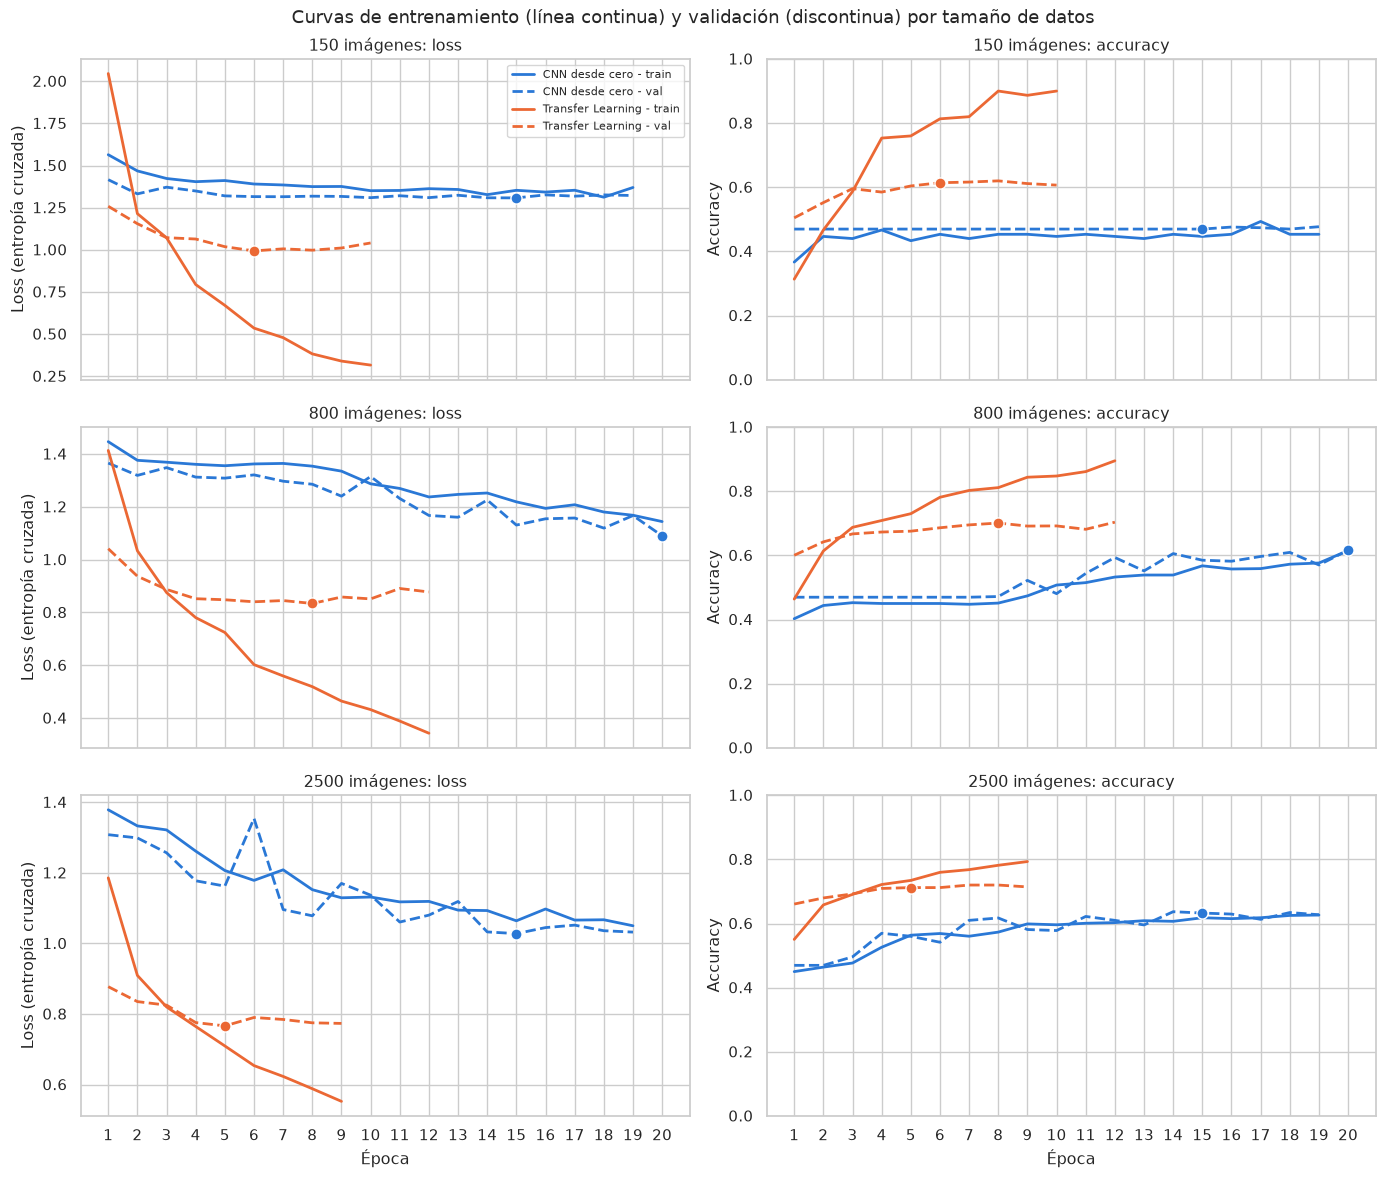

In [23]:
fig, axes = plt.subplots(len(TRAIN_SIZES), 2, figsize=(14, 12), sharex=True)
for i, n in enumerate(TRAIN_SIZES):
    for enfoque in ENFOQUES:
        r = experimentos[(enfoque, n)]
        h, color = r["history"], COLORES[enfoque]
        epocas = range(1, len(h["loss"]) + 1)
        for j, metrica in enumerate(["loss", "accuracy"]):
            ax = axes[i, j]
            ax.plot(epocas, h[metrica], color=color, lw=2, label=f"{enfoque} - train")
            ax.plot(epocas, h[f"val_{metrica}"], color=color, lw=2, ls="--", label=f"{enfoque} - val")
            ax.plot(r["mejor_epoca"], h[f"val_{metrica}"][r["mejor_epoca"] - 1], "o", color=color, ms=8,
                    markeredgecolor="white")
    axes[i, 0].set_title(f"{n} imágenes: loss")
    axes[i, 1].set_title(f"{n} imágenes: accuracy")
    axes[i, 0].set_ylabel("Loss (entropía cruzada)")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].set_ylim(0, 1)
for ax in axes[-1]:
    ax.set_xlabel("Época")
    ax.set_xticks(range(1, EPOCHS + 1))
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.suptitle("Curvas de entrenamiento (línea continua) y validación (discontinua) por tamaño de datos", fontsize=13)
plt.tight_layout()
plt.show()

**Resultado e interpretación de las curvas.**

- **150 imágenes.** La CNN desde cero está **subajustada**: loss de entrenamiento y validación planas alrededor de 1.35-1.40 y accuracy fija en ~0.45-0.47 durante 19 épocas. Con 5 pasos por época, 20 épocas son solo ~100 actualizaciones de gradiente partiendo de filtros aleatorios: insuficiente para que la red salga de la solución trivial. El transfer learning muestra el patrón opuesto, **sobreajuste rápido**: la loss de entrenamiento cae de 2.05 a 0.32 y la accuracy de entrenamiento sube a 0.90, mientras la `val_loss` toca su mínimo (0.994) en la época 6 y vuelve a subir; `EarlyStopping` corta en la 10 y `restore_best_weights` devuelve la época 6. Con 150 imágenes la cabeza de 165 k parámetros memoriza el conjunto de entrenamiento, y el `Dropout(0.5)` solo lo retrasa.
- **800 imágenes.** La CNN empieza a aprender a partir de la época ~8, y en la época 20 su `val_loss` (1.090) **todavía va bajando**: el tope de 20 épocas la deja a medio camino, y las curvas de train y val van casi pegadas (no hay sobreajuste, hay falta de entrenamiento). El transfer learning alcanza su mínimo (0.834) en la época 8 y la brecha train/val se abre (accuracy 0.90 vs 0.70 en la época 12).
- **2500 imágenes.** La CNN sigue con train y val superpuestas (sesgo alto, varianza baja) y una `val_loss` ruidosa (pico de 1.35 en la época 6) que se estabiliza en ~1.03-1.05; una arquitectura tan pequeña (110 k parámetros) y sin *data augmentation* satura pronto. El transfer learning converge en 5 épocas a `val_loss` = 0.766 y luego sobreajusta suavemente (train 0.79 vs val 0.71 en la época 9).
- **Lectura conjunta:** al aumentar los datos, la CNN pasa de "no aprende" a "aprende lento y satura", mientras que el transfer learning pasa de "sobreajuste severo" a "sobreajuste moderado" con un mínimo de `val_loss` cada vez más bajo. `EarlyStopping` con `patience=4` es adecuado para el transfer learning (curvas suaves), pero para la CNN su efecto principal fue cortar en la época 19 un entrenamiento que aún mejoraba lentamente.

# **5. Análisis e interpretación**

### **Pregunta 1. ¿Cómo cambia la diferencia de desempeño entre la CNN desde cero y transfer learning al aumentar la cantidad de datos? ¿Por qué ocurre?**

**Qué observamos.** La brecha a favor del transfer learning es máxima con 150 imágenes y se reduce, pero no desaparece, al aumentar los datos:

| Métrica en test | Brecha (TL − CNN) con 150 | con 800 | con 2500 |
|-|-|-|-|
| Accuracy | +0.145 | +0.077 | +0.087 |
| Balanced accuracy | +0.224 | +0.218 | +0.227 |
| F1 macro | +0.315 | +0.283 | +0.307 |
| F1 de CBB | +0.173 | +0.258 | +0.299 |

En **accuracy global** la brecha se reduce casi a la mitad (de 0.145 a ~0.08) al pasar de 150 a 800 imágenes y después se mantiene. Pero en **balanced accuracy y F1 macro la brecha es constante** (~0.22 y ~0.30) y en el **F1 de CBB incluso crece**: la CNN cierra distancia únicamente en las clases mayoritarias.

**Por qué ocurre.**

1. **Punto de partida.** MobileNetV2 llega con 2.26 M de parámetros que ya codifican bordes, texturas, colores y formas aprendidos en 1.2 M de imágenes de ImageNet. Con el backbone congelado, el transfer learning solo tiene que ajustar una cabeza de 165 k parámetros sobre un vector de 1280 características ya discriminativas: un problema casi lineal y, por tanto, muy eficiente en datos. La CNN desde cero, en cambio, debe descubrir sus 110 k parámetros (los filtros incluidos) a partir de las mismas imágenes. Con 150 imágenes (≈100 actualizaciones de gradiente en 20 épocas) el gradiente es demasiado débil y ruidoso: la red no sale del clasificador mayoritario (accuracy 0.470, todas las predicciones `cmd`).

2. **A medida que hay más datos**, la CNN empieza a aprender los patrones más frecuentes y contrastados (`cmd` y `cbsd`, que son el 72 % de las imágenes) y su accuracy global sube a 0.62-0.63, acercándose al transfer learning. Sin embargo, para las clases con pocos ejemplos y síntomas sutiles (CBB, `cgm`, `healthy`) 2500 imágenes siguen sin bastar para aprender filtros específicos desde cero: F1 = 0 en `cgm` y `healthy`. Por eso la brecha en las métricas balanceadas no se cierra.

3. **Rendimientos decrecientes.** De 800 a 2500 imágenes ambos enfoques mejoran poco (+0.012 y +0.022 de accuracy). La CNN está limitada por su capacidad (arquitectura pequeña, sin *augmentation*, 20 épocas), y el transfer learning por el backbone congelado (características genéricas de ImageNet, no específicas de hojas de yuca). Esperaríamos que la brecha en accuracy siguiera reduciéndose con decenas de miles de imágenes y una CNN más grande, pero en el rango de datos del taller las características preentrenadas dominan claramente.

### **Pregunta 2. ¿Cómo evoluciona el desempeño de la clase CBB al aumentar la cantidad de datos en cada enfoque?**

| Imágenes (ejemplos de CBB) | CNN: F1 / precisión / recall | TL: F1 / precisión / recall |
|-|-|-|
| 150 (15 de CBB) | 0.000 / 0.00 / 0.00 | 0.173 / 0.24 / 0.14 |
| 800 (76 de CBB) | 0.085 / 0.78 / 0.05 | 0.344 / 0.44 / 0.28 |
| 2500 (217 de CBB) | 0.073 / 0.67 / 0.04 | 0.372 / 0.52 / 0.29 |

- **CNN desde cero: CBB nunca se aprende.** Con 15 ejemplos el recall es 0 (las 155 hojas con CBB del test se predicen `cmd`). Con 76 y 217 ejemplos la red acierta 7 y 6 hojas respectivamente: precisión alta (0.67-0.78) pero recall del 4-5 %, y el F1 incluso baja ligeramente de 800 a 2500. Más datos no ayudan porque la red no desarrolla filtros para las manchas de CBB; las hojas con CBB se van a `cbsd` (113-117 de 155). Para la CNN, CBB es una clase "invisible" en todo el rango de datos.

- **Transfer learning: mejora monótona pero con techo bajo.** F1 0.173 → 0.344 → 0.372. El salto grande ocurre de 15 a 76 ejemplos (el modelo pasa de detectar 21 a 44 de las 155 hojas con CBB); de 76 a 217 ejemplos la mejora es pequeña (45 aciertos) y viene por la precisión (0.44 → 0.52), no por el recall (0.28 → 0.29). Es decir, con más datos el modelo es más confiable cuando dice "CBB", pero sigue sin encontrar 7 de cada 10 casos.

- **Eficiencia por ejemplo.** El transfer learning con 76 ejemplos de CBB (F1 0.344) supera con amplitud a la CNN con 217 (F1 0.073): las características preentrenadas valen más que el triple de datos para la clase minoritaria.

- **Por qué CBB se estanca en ~0.37 incluso con transfer learning.** La matriz de confusión muestra que el error dominante es CBB → `cbsd` (69 de 155 con 2500 imágenes). Ambas enfermedades producen manchas y amarillamiento en la lámina de la hoja y, a 160×160, la diferencia (necrosis angular y bordes quemados en CBB frente a estrías junto a las venas en CBSD) queda en muy pocos píxeles. Que `healthy`, con menos ejemplos (133) llegue a F1 0.618 confirma que el problema de CBB es más de **similitud visual con una clase 3 veces más frecuente** que de escasez pura. Mejorar CBB exigiría acciones que el protocolo del taller no incluye: pesos de clase o sobremuestreo, *data augmentation*, mayor resolución o *fine-tuning* de las últimas capas del backbone.

### **Pregunta 3. Si solo dispusieran de aproximadamente 150 imágenes etiquetadas, ¿qué enfoque recomendarían y por qué?**

**Recomendamos transfer learning con el backbone congelado**, sin dudarlo, por la evidencia del experimento de 150 imágenes:

| Métrica en test (150 imágenes) | CNN desde cero | Transfer Learning |
|-|-|-|
| Accuracy | 0.470 (= predecir siempre `cmd`) | 0.615 |
| Balanced accuracy | 0.200 (azar entre 5 clases) | 0.424 |
| F1 macro | 0.128 | 0.443 |
| F1 de CBB | 0.000 | 0.173 |
| Clases con F1 > 0 | 1 de 5 | 5 de 5 |

1. **La CNN desde cero es inútil con 150 imágenes:** equivale a un clasificador mayoritario, no detecta ninguna enfermedad distinta de `cmd` y sus curvas muestran que no está aprendiendo (loss plana). Ninguna cantidad razonable de épocas cambiaría eso: el cuello de botella es la información disponible para aprender filtros desde cero.
2. **El transfer learning aprovecha conocimiento externo:** con 15 ejemplos de CBB ya detecta 21 de 155 casos en test y obtiene F1 > 0.3 en `cgm` y `healthy`. Su accuracy con 150 imágenes (0.615) es casi la de la CNN con 2500 (0.631): el backbone preentrenado equivale a multiplicar por ~16 el conjunto de datos.
3. **Es más barato y rápido:** converge en 6 épocas (38 s) y solo entrena 165 k parámetros.
4. **Precauciones con tan pocos datos.** Las curvas muestran sobreajuste severo (accuracy de entrenamiento 0.90 frente a 0.61 en validación), así que son imprescindibles `EarlyStopping` con `restore_best_weights` (como aquí), `Dropout` y, si se saliera del protocolo del taller, *data augmentation* (flips, rotaciones, cambios de brillo, que son realistas para fotos de campo). **No** recomendaríamos hacer *fine-tuning* del backbone con 150 imágenes: descongelar 2.26 M de parámetros con 5 lotes por época destruiría las características preentrenadas y sobreajustaría aún más.

### **Pregunta 4. ¿En qué escenario podría no ser conveniente utilizar transfer learning?**

Nuestros resultados muestran al transfer learning ganando en los tres tamaños, pero también dejan ver sus límites. A partir de ellos identificamos cuatro escenarios en los que dejaría de ser la mejor opción:

1. **Cambio de dominio respecto a ImageNet.** El transfer learning funcionó porque las hojas de yuca son fotografías RGB naturales, el mismo tipo de imagen con el que se preentrenó MobileNetV2 (sus filtros de bordes, texturas y colores transfieren directamente). Si las entradas fueran imágenes multiespectrales o térmicas de dron, radiografías, espectrogramas o imágenes de un solo canal, las características preentrenadas serían poco relevantes (y ni siquiera aceptarían el número de canales sin adaptación); una CNN diseñada para ese dominio podría igualar o superar al backbone congelado con muchos menos datos de los que sugiere este taller.

2. **Abundancia de datos y presupuesto de cómputo.** La brecha en accuracy se redujo de 0.145 a ~0.08 al pasar de 150 a 800-2500 imágenes, y el transfer learning con backbone congelado ya muestra señales de techo (de 800 a 2500 imágenes solo ganó +0.022 de accuracy y `cbsd` no mejoró). Con decenas de miles de imágenes etiquetadas, una CNN más profunda entrenada desde cero (o con *fine-tuning* completo) puede aprender características específicas del cultivo (por ejemplo, las estrías finas de CBSD) que un extractor genérico congelado nunca va a producir.

3. **Restricciones extremas de despliegue.** MobileNetV2 ya es un modelo "ligero", pero pesa 9.2 MB y calcula 2.4 M de parámetros por imagen, frente a 0.4 MB y 110 k parámetros de la CNN desde cero (22 veces menos). En un microcontrolador o en un teléfono de gama muy baja sin conexión, o cuando se procesan miles de imágenes por segundo, ese costo puede ser decisivo, y una CNN pequeña entrenada con suficientes datos sería la opción viable.

4. **Cuando la tarea exige características que el backbone congelado no captura y no se puede afinar.** El F1 de CBB se estancó en 0.37 aunque triplicamos los ejemplos: las características genéricas no separan bien CBB de CBSD. Si no es posible hacer *fine-tuning* (por falta de datos, de cómputo o por restricciones de licencia del modelo preentrenado), el transfer learning "congelado" impone un techo que un modelo propio, con datos suficientes, podría superar.

Adicionalmente, con muy pocos datos el transfer learning **sobreajusta muy rápido** (accuracy de entrenamiento 0.90 con `val_loss` subiendo desde la época 6): sin `EarlyStopping` y regularización adecuados, su ventaja puede desperdiciarse. En el escenario concreto de este taller (fotos naturales, entre 150 y 2500 imágenes, despliegue en teléfonos comunes) ninguno de esos escenarios aplica, y el transfer learning es claramente la elección correcta.

# **6. Conclusiones**

**Resumen de los seis experimentos (métricas en test, mismo conjunto de validación y test en todos):**

| Imágenes | Enfoque | Accuracy | Balanced acc. | F1 macro | F1 CBB | Épocas (mejor) |
|-|-|-|-|-|-|-|
| 150 | CNN desde cero | 0.470 | 0.200 | 0.128 | 0.000 | 19 (15) |
| 150 | Transfer Learning | **0.615** | **0.424** | **0.443** | **0.173** | 10 (6) |
| 800 | CNN desde cero | 0.619 | 0.339 | 0.294 | 0.085 | 20 (20) |
| 800 | Transfer Learning | **0.696** | **0.557** | **0.577** | **0.344** | 12 (8) |
| 2500 | CNN desde cero | 0.631 | 0.346 | 0.299 | 0.073 | 19 (15) |
| 2500 | Transfer Learning | **0.718** | **0.573** | **0.606** | **0.372** | 9 (5) |

**Conclusiones principales.**

1. **Transfer learning domina en todo el rango de datos del taller.** Con 150 imágenes es la diferencia entre un modelo útil (accuracy 0.615, cinco clases detectadas) y un clasificador mayoritario (0.470, una sola clase). Con 2500 imágenes la ventaja persiste: +0.087 de accuracy y +0.227 de balanced accuracy.
2. **La cantidad de datos ayuda a ambos, pero de forma distinta.** La CNN desde cero solo aprende las dos clases mayoritarias y satura en ~0.63 de accuracy; el transfer learning mejora en las cinco clases y sigue ganando con más datos, aunque con rendimientos decrecientes a partir de 800 imágenes.
3. **CBB es el punto débil de los dos enfoques.** La CNN no la detecta (recall ≤ 5 %) y el transfer learning se queda en F1 0.37 porque la confunde con CBSD. En una aplicación real como Nuru, esto implicaría no alertar a 7 de cada 10 agricultores con bacteriosis: el desbalance y la similitud visual entre enfermedades, no la cantidad total de datos, son el problema a atacar.
4. **El protocolo común (160×160, 20 épocas, `EarlyStopping` con `patience=4`) trata de forma distinta a los dos enfoques**: es suficiente para que el transfer learning converja (5-8 épocas) pero deja a la CNN desde cero a medio entrenar (con 800 imágenes su mejor época fue la 20). Ese sesgo es parte del hallazgo: en un presupuesto fijo de cómputo, el transfer learning también es más eficiente.

**Limitaciones y trabajo futuro.** Los resultados provienen de una sola semilla (reproducible gracias a `enable_op_determinism`), sin *data augmentation* ni pesos de clase, y con un único backbone. Los siguientes pasos naturales, fuera del alcance del taller, serían: (i) `class_weight` o sobremuestreo de CBB y `healthy`; (ii) *augmentation* realista para fotos de campo; (iii) *fine-tuning* de los últimos bloques de MobileNetV2 con una tasa de aprendizaje baja en el experimento de 2500 imágenes; (iv) comparar con EfficientNetB0 y con mayor resolución de entrada; y (v) repetir con varias semillas para estimar la varianza de las métricas, especialmente el F1 de CBB, que depende de solo 155 imágenes de test.